In [31]:
from rdkit import Chem

sdf_name = '7x9p_ligand' # Put your sdf file here (ex. 6xox.sdf -> 6xox)

mol = Chem.SDMolSupplier(
    f"{sdf_name}.sdf",
    sanitize=False,
    removeHs=False
)[0]

In [32]:
from rdkit.Chem import Draw
from rdkit.Chem import rdDepictor
from collections import deque
from IPython.display import display
from collections import deque

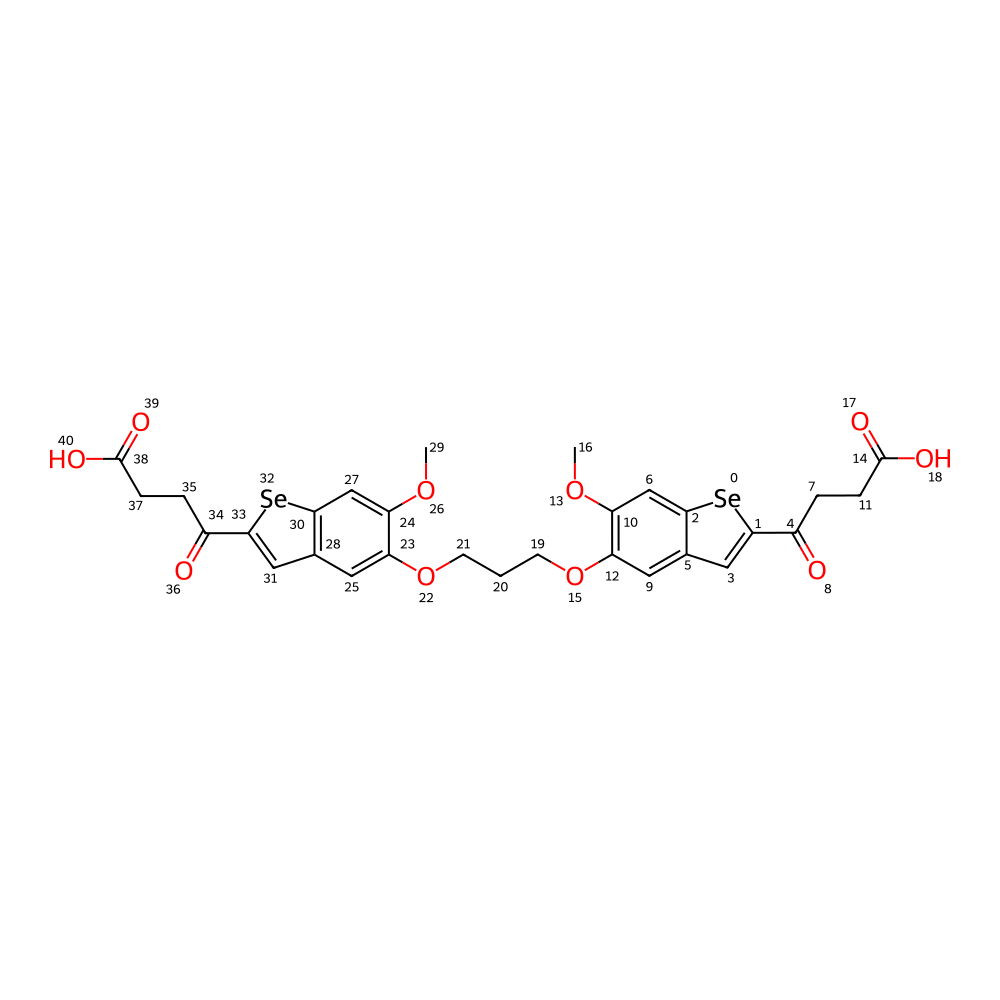

In [33]:
def renumber_by_bfs(mol, start_atom=None):
    """
    Renumber atoms by breadth-first search (BFS) along bonds.

    mol : rdkit.Chem.Mol
    start_atom : int or None (Atom index to start BFS from. If None, atom 0 is used)

    Returns: rdkit.Chem.Mol (New molecule with reordered atom indices.)
    """

    if start_atom is None:
        start_atom = 0

    visited = set()
    order = []

    queue = deque([start_atom])

    while queue:
        idx = queue.popleft()

        if idx in visited:
            continue

        visited.add(idx)
        order.append(idx)

        neighbors = sorted(
            nbr.GetIdx()
            for nbr in mol.GetAtomWithIdx(idx).GetNeighbors()
            if nbr.GetIdx() not in visited
        )

        queue.extend(neighbors)

    return Chem.RenumberAtoms(mol, order)

renumbered_mol = renumber_by_bfs(mol)

rdDepictor.SetPreferCoordGen(True)
rdDepictor.Compute2DCoords(renumbered_mol)

drawer = Draw.rdMolDraw2D.MolDraw2DCairo(1000, 1000)
opts = drawer.drawOptions()
opts.addAtomIndices = True

drawer.DrawMolecule(renumbered_mol)
drawer.FinishDrawing()

from IPython.display import Image
display(Image(drawer.GetDrawingText()))

In [34]:
def keep_atoms(mol, atoms_to_keep):
    """
    Keep only the specified atoms and return a new molecule.
    """

    max_idx = mol.GetNumAtoms() - 1

    if not all(0 <= idx <= max_idx for idx in atoms_to_keep):
        raise ValueError("atoms_to_keep contains an invalid atom index.")

    keep = set(atoms_to_keep)

    rwmol = Chem.RWMol(mol)

    atoms_to_remove = sorted(
        [
            atom.GetIdx()
            for atom in rwmol.GetAtoms()
            if atom.GetIdx() not in keep
        ],
        reverse=True
    )

    for idx in atoms_to_remove:
        rwmol.RemoveAtom(idx)

    newmol = rwmol.GetMol()
    
    try:
        Chem.SanitizeMol(newmol)
    except Exception as e:
        raise RuntimeError(f"Sanitize failed:\n{e}")

    return newmol

In [35]:
def parse_atom_indices(text):

    atoms = []

    for token in text.split(","):
        token = token.strip()

        if "-" in token:
            start, end = token.split("-")
            start = int(start)
            end = int(end)

            if start > end:
                raise ValueError(f"Invalid range: {token}")

            atoms.extend(range(start, end + 1))

        else:
            atoms.append(int(token))

    return sorted(set(atoms))


print("You can select atoms_to_keep now!")

You can select atoms_to_keep now!


In [ ]:
user_input = input("Atoms to keep (e.g. 0-10, 15, 20-25): ") # input your atoms to keep

atoms_to_keep = parse_atom_indices(user_input)

print(atoms_to_keep)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


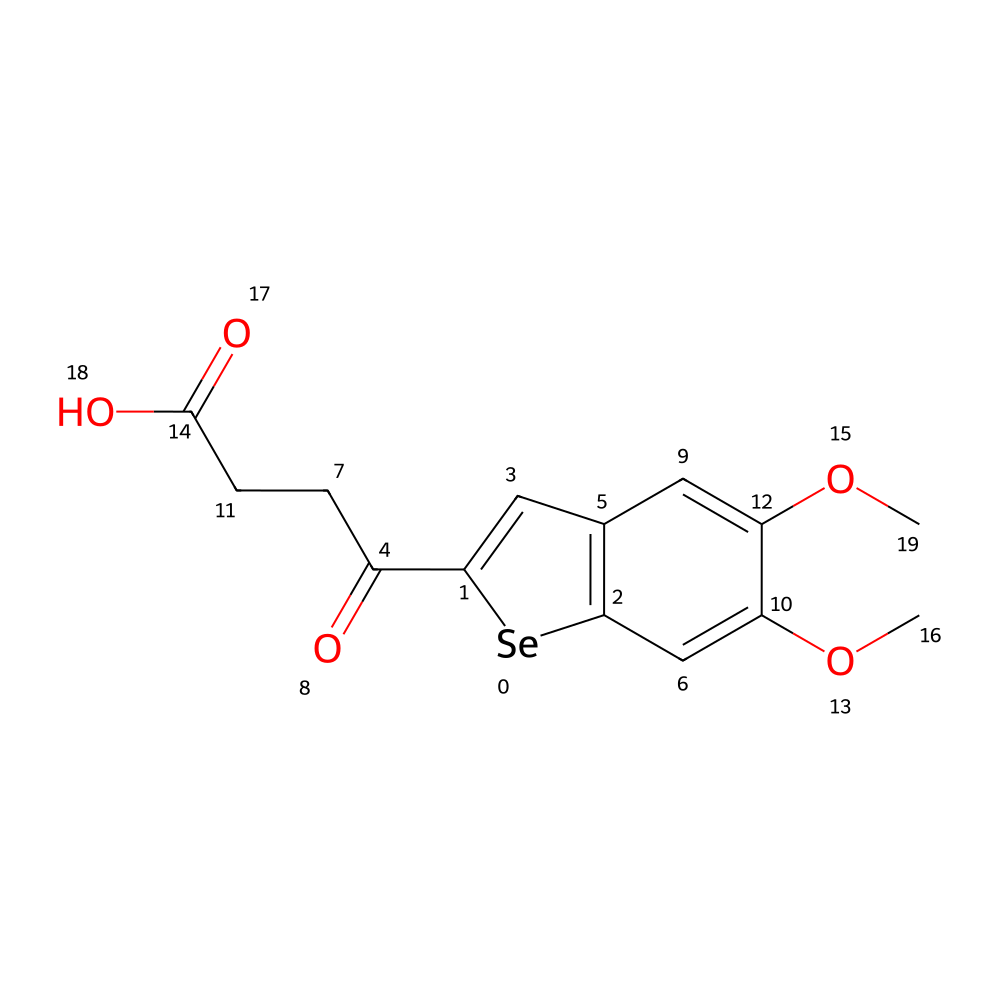

In [37]:
newmol = keep_atoms(renumbered_mol, atoms_to_keep)

mol_draw = Chem.Mol(newmol)

rdDepictor.SetPreferCoordGen(True)
rdDepictor.Compute2DCoords(mol_draw)

drawer = Draw.rdMolDraw2D.MolDraw2DCairo(1000, 1000)
opts = drawer.drawOptions()
opts.addAtomIndices = True

drawer.DrawMolecule(mol_draw)
drawer.FinishDrawing()

display(Image(drawer.GetDrawingText()))

In [38]:
# Save it to sdf!

writer = Chem.SDWriter(f"{sdf_name}_pharmacophore.sdf")
writer.write(newmol)
writer.close()